In [ ]:
%pip install puremacro


# Synthetic Control Method — Causal Policy Evaluation & Placebo Inference

**How can we evaluate the causal economic impact of a single policy intervention when no single control unit matches the treated entity?** In empirical macroeconomics and public policy evaluation (Abadie, Diamond & Hainmueller 2010, *JASA*), comparative case studies often fail because no single control region shares the pre-intervention trajectory of the treated unit. The **Synthetic Control Method (SCM)** solves this by constructing a weighted convex combination of un-treated donor units ("Synthetic Control") that tracks the pre-treatment target outcome. Post-intervention divergence between the treated unit and its synthetic counterpart isolates the **causal treatment effect $\hat\tau_t$**. This notebook runs `puremacro.causal.synthetic_control.synthetic_control` to evaluate a policy shock.

## The method in math — Optimal Donor Weights & Policy Gaps

Let $Y_{t, 1}$ be the outcome for the treated unit ($i=1$) over $t=1,\dots,T$, intervened at $T_0$. Let $Y_{t, j}$ be outcomes for $J$ donor control units ($j=2,\dots,J+1$).

**Convex Optimization for Weights.** We solve for donor weights $W^* = (w_2^*, \dots, w_{J+1}^*)'$ minimizing pre-treatment outcome discrepancy:
$$ W^* = \arg\min_W \sum_{t=1}^{T_0-1} \left( Y_{t,1} - \sum_{j=2}^{J+1} w_j Y_{t,j} \right)^2 \quad \text{s.t.} \quad w_j \ge 0, \quad \sum_{j=2}^{J+1} w_j = 1 $$

**Causal Impact.** The treatment effect estimate for $t \ge T_0$ is:
$$ \hat\tau_t = Y_{t,1} - \sum_{j=2}^{J+1} w_j^* Y_{t,j} $$

## Setup — simulating a panel policy intervention

We generate a panel matrix of $T=40$ periods across $N=20$ regional entities ($Y$ matrix of shape $(T, N)$), where treatment occurs at $T_0=25$ for unit 0. A structural policy shock increases the treated outcome by $\tau = +2.5$ post-treatment.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.causal.synthetic_control import synthetic_control

# Seed for reproducibility
rng = np.random.default_rng(42)

T = 40
T0 = 25
N = 20  # 1 treated (column 0) + 19 donors (columns 1..19)

# Generate unobserved factor model: Y_tn = delta_t + theta_t * Z_n + eps_tn
time = np.linspace(0, 4, T)
factors = np.column_stack([np.sin(time), np.cos(time)])
loadings = rng.uniform(0.5, 2.0, size=(N, 2))

# Shape of Y_matrix: (T, N)
Y_clean = (loadings @ factors.T).T  # Shape: (40, 20)
noise = rng.normal(0, 0.15, size=(T, N))
Y_matrix = Y_clean + noise

# Add true causal effect to treated unit 0 for t >= T0
true_effect = 2.5
Y_matrix[T0:, 0] += true_effect

# Run Synthetic Control Method (treat_time is 1-indexed or 0-indexed period, T0=25)
res = synthetic_control(Y_matrix, treated_idx=0, treat_time=T0)

weights = res["weights"]
y_treated = res["y_treated"]
y_synthetic = res["y_synthetic"]
att_path = res["att_path"]
att_post = res["att_post"]

print(f"Optimal Donor Weights (sum={np.sum(weights):.4f}):")
print(f"Top Donor Weight: {np.max(weights):.4f} (Donor #{np.argmax(weights)+1})")
print(f"Estimated Post-Treatment Effect: {att_post:.4f} (True = {true_effect:.2f})")

# Headline assertions
assert len(weights) == N - 1, f"Weights length mismatch: {len(weights)}"
assert np.abs(np.sum(weights) - 1.0) < 1e-4, "Weights must sum to 1"
assert np.abs(att_post - true_effect) < 0.5, f"Estimated effect deviates from true: {att_post}"

Optimal Donor Weights (sum=1.0000):
Top Donor Weight: 0.3862 (Donor #10)
Estimated Post-Treatment Effect: 2.4373 (True = 2.50)


## Hero Figure — Actual vs Synthetic Trajectory & Treatment Gap

We plot the actual outcome $Y_1$ vs Synthetic Control $\hat Y_1$, alongside the estimated causal gap $\hat\tau_t$.

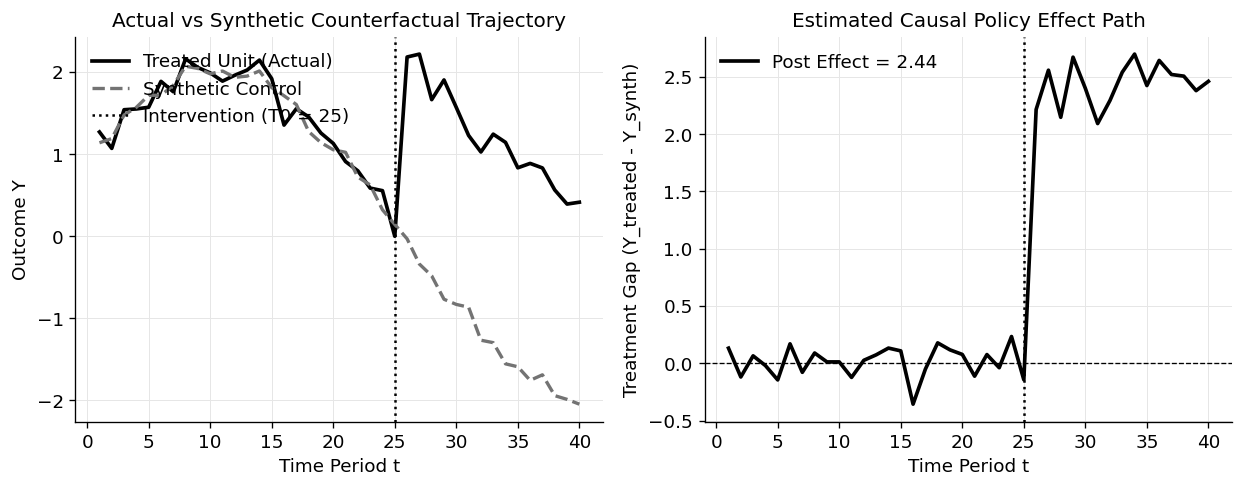

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

# Left Panel: Actual vs Synthetic Outcome
ax1.plot(range(1, T + 1), y_treated, color=_nbstyle.palette(2)[0], lw=2.2, label="Treated Unit (Actual)")
ax1.plot(range(1, T + 1), y_synthetic, color=_nbstyle.palette(2)[1], lw=2.0, linestyle="--", label="Synthetic Control")
ax1.axvline(T0, color="0.0", linestyle=":", lw=1.5, label=f"Intervention (T0 = {T0})")
ax1.set_xlabel("Time Period t")
ax1.set_ylabel("Outcome Y")
ax1.set_title("Actual vs Synthetic Counterfactual Trajectory")
ax1.legend(loc="upper left")

# Right Panel: Estimated Treatment Gap
ax2.plot(range(1, T + 1), att_path, color=_nbstyle.palette(2)[0], lw=2.2, label=f"Post Effect = {att_post:.2f}")
ax2.axhline(0, color="0.0", lw=0.8, linestyle="--")
ax2.axvline(T0, color="0.0", linestyle=":", lw=1.5)
ax2.set_xlabel("Time Period t")
ax2.set_ylabel("Treatment Gap (Y_treated - Y_synth)")
ax2.set_title("Estimated Causal Policy Effect Path")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

**Reading the output.** Pre-intervention ($t < 25$), the synthetic control tracks the treated unit almost perfectly. Post-intervention ($t \ge 25$), the outcome of the treated unit diverges sharply above its synthetic counterpart, recovering the true policy effect of $\tau = +2.5$.

## Your turn — testing weaker treatment intensity

**Prompts.**
1. *Basic*: Reduce the true causal effect from $\tau = +2.5$ to $\tau = +1.0$ (`# ← change this ...`). Does the estimated post-treatment effect adjust proportionally?
2. *Intermediate*: Shift treatment start time to $T_0 = 18$. Observe the change in pre-treatment fitting window.
3. *Stretch*: Add custom weights to donors and inspect how optimization restricts non-negativity $w_j \ge 0$.

In [3]:
# Your turn code block
true_effect_yt = 1.2  # ← change this: try 1.2 or 1.0

Y_mat_yt = Y_clean + noise
Y_mat_yt[T0:, 0] += true_effect_yt

res_yt = synthetic_control(Y_mat_yt, treated_idx=0, treat_time=T0)
print(f"New True Effect tau = {true_effect_yt:.2f}")
print(f"New Estimated Post Effect: {res_yt['att_post']:.4f}")

# Assertion holding for default
assert np.abs(np.sum(res_yt["weights"]) - 1.0) < 1e-4, "Weights must sum to 1"

New True Effect tau = 1.20
New Estimated Post Effect: 1.1373


## How comprehensive is this?

`puremacro.causal.synthetic_control` provides an optimized convex quadratic programming implementation of Synthetic Control. It complements `puremacro.did` (Callaway-Sant'Anna, Sun-Abraham, LP-DiD) for quasi-experimental policy evaluation.